# 03 — Baseline Models: FD001

Continues from 02_feature_engineering.ipynb. Covers:
- Linear Regression (with scaling)
- Random Forest
- XGBoost
- Comparing all three on validation set using RMSE + NASA asymmetric score

See DECISIONS3.md for reasoning behind each choice made here.

NOTE ON GPU: scikit-learn (Linear Regression, Random Forest) and XGBoost's
default CPU mode do not use GPU acceleration on any machine — this is a
library limitation, not specific to Mac. GPU (via PyTorch MPS on this M2)
becomes relevant starting in the next phase (sequence models / LSTM).

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import SENSOR_COLS
from src.data_loader import load_subset
from src.preprocessing import add_rul_to_train, add_rul_to_test
from src.evaluation import rmse, nasa_score, evaluate

pd.set_option("display.max_columns", 40)

## Rebuild train_final / test_final from scratch
(Self-contained, same as previous notebooks — doesn't rely on variables
still in memory from 02_feature_engineering.ipynb.)

In [2]:
train, test, rul_truth = load_subset("FD001")
train = add_rul_to_train(train)
test = add_rul_to_test(test, rul_truth)

constant_sensors = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]
train_reduced = train.drop(columns=constant_sensors)
test_reduced = test.drop(columns=constant_sensors)
sensor_cols_remaining = [c for c in SENSOR_COLS if c not in constant_sensors]


def engineer_features(df, sensor_cols, windows=[5, 10]):
    """
    Applies baseline normalization, rolling mean, and rolling std
    to a CMAPSS dataframe (train OR test) — entirely per-engine,
    so it's safe to call independently on each. See DECISIONS2.md
    for reasoning behind each step.
    """
    df = df[["unit_number", "time_in_cycles", "RUL"] + sensor_cols].copy()

    for sensor in sensor_cols:
        baseline_avg = (
            df[df["time_in_cycles"] <= 10]
            .groupby("unit_number")[sensor]
            .mean()
        )
        baseline_mapped = df["unit_number"].map(baseline_avg)
        df[f"{sensor}_norm"] = df[sensor] - baseline_mapped

    for window in windows:
        for sensor in sensor_cols:
            for suffix in ["", "_norm"]:
                col = f"{sensor}{suffix}"
                new_col = f"{col}_rollmean_{window}"
                df[new_col] = (
                    df.groupby("unit_number")[col]
                    .rolling(window=window, min_periods=1)
                    .mean()
                    .reset_index(level=0, drop=True)
                )

    for window in windows:
        for sensor in sensor_cols:
            new_col = f"{sensor}_rollstd_{window}"
            df[new_col] = (
                df.groupby("unit_number")[sensor]
                .rolling(window=window, min_periods=1)
                .std()
                .reset_index(level=0, drop=True)
                .fillna(0)
            )

    return df


train_final = engineer_features(train_reduced, sensor_cols_remaining)
test_final = engineer_features(test_reduced, sensor_cols_remaining)

print("train_final:", train_final.shape)
print("test_final:", test_final.shape)
assert train_final.shape[1] == test_final.shape[1]

train_final: (20631, 115)
test_final: (13096, 115)


## Engine-level train/validation split (see DECISIONS2.md entry 8 for why
this must be split by engine, not by row)

In [3]:
np.random.seed(42)
all_engine_ids = train_final["unit_number"].unique()
np.random.shuffle(all_engine_ids)

n_val_engines = 20
val_engine_ids = all_engine_ids[:n_val_engines]
train_engine_ids = all_engine_ids[n_val_engines:]

train_split = train_final[train_final["unit_number"].isin(train_engine_ids)]
val_split = train_final[train_final["unit_number"].isin(val_engine_ids)]

print("Train engines:", len(train_engine_ids), "-> rows:", train_split.shape[0])
print("Val engines:", len(val_engine_ids), "-> rows:", val_split.shape[0])

Train engines: 80 -> rows: 16561
Val engines: 20 -> rows: 4070


## Ready for modeling

In [4]:
# Columns that are NOT features — identifiers and the target itself
non_feature_cols = ["unit_number", "time_in_cycles", "RUL"]
feature_cols = [c for c in train_split.columns if c not in non_feature_cols]

X_train = train_split[feature_cols]
y_train = train_split["RUL"]

X_val = val_split[feature_cols]
y_val = val_split["RUL"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Number of features:", len(feature_cols))

X_train: (16561, 112)
X_val: (4070, 112)
Number of features: 112


#### Scaling features for Linear Regression

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform on train: LEARNS the mean/std from train, then scales train using them
X_train_scaled = scaler.fit_transform(X_train)

# transform (NOT fit_transform) on val: reuses the mean/std already learned from train
X_val_scaled = scaler.transform(X_val)

print("X_train_scaled mean (should be ~0):", X_train_scaled.mean())
print("X_train_scaled std (should be ~1):", X_train_scaled.std())

X_train_scaled mean (should be ~0): 4.2895477277580695e-14
X_train_scaled std (should be ~1): 0.9999999999999996


In [6]:
import numpy as np
print(np.isclose(X_train_scaled.mean(), 0))   # True if "close enough" to 0
print(np.isclose(X_train_scaled.std(), 1))    # True if "close enough" to 1

True
True


### Modeling: Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# predict on both train and val — we check train too, to see if the model
# is even capable of fitting the data it learned from
y_train_pred = lr_model.predict(X_train_scaled)
y_val_pred = lr_model.predict(X_val_scaled)

train_metrics = evaluate(y_train, y_train_pred)
val_metrics = evaluate(y_val, y_val_pred)

print("Train metrics:", train_metrics)
print("Val metrics:", val_metrics)

Train metrics: {'rmse': 15.787399306375805, 'nasa_score': 65103.89210266182}
Val metrics: {'rmse': 16.42428088838614, 'nasa_score': 19569.006835664506}


In [8]:
print("Train NASA score per row:", train_metrics["nasa_score"] / len(y_train))
print("Val NASA score per row:", val_metrics["nasa_score"] / len(y_val))

Train NASA score per row: 3.9311570619323604
Val NASA score per row: 4.8081097876325565


### Ridge Regression

In [9]:
from sklearn.linear_model import Ridge

alpha_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

ridge_results = []

for alpha in alpha_values:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)

    y_val_pred = ridge_model.predict(X_val_scaled)
    metrics = evaluate(y_val, y_val_pred)

    ridge_results.append({
        "alpha": alpha,
        "val_rmse": metrics["rmse"],
        "val_nasa_per_row": metrics["nasa_score"] / len(y_val),
    })

ridge_results_df = pd.DataFrame(ridge_results)
print(ridge_results_df)

      alpha   val_rmse  val_nasa_per_row
0     0.001  16.424278          4.808106
1     0.010  16.424249          4.808071
2     0.100  16.423964          4.807720
3     1.000  16.421154          4.804265
4    10.000  16.396597          4.773657
5   100.000  16.265469          4.601133
6  1000.000  15.933628          4.180481


In [10]:
alpha_values_extended = [1000, 5000, 10000, 50000, 100000, 500000, 1000000]

ridge_results_extended = []

for alpha in alpha_values_extended:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)

    y_val_pred = ridge_model.predict(X_val_scaled)
    metrics = evaluate(y_val, y_val_pred)

    ridge_results_extended.append({
        "alpha": alpha,
        "val_rmse": metrics["rmse"],
        "val_nasa_per_row": metrics["nasa_score"] / len(y_val),
    })

ridge_results_extended_df = pd.DataFrame(ridge_results_extended)
print(ridge_results_extended_df)

     alpha   val_rmse  val_nasa_per_row
0     1000  15.933628          4.180481
1     5000  15.694192          3.954313
2    10000  15.619948          3.888476
3    50000  15.666494          3.824097
4   100000  16.070091          3.995544
5   500000  21.048840          7.534689
6  1000000  25.804407         14.581749


In [11]:
alpha_values_narrow = [10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000]

ridge_results_narrow = []

for alpha in alpha_values_narrow:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)

    y_val_pred = ridge_model.predict(X_val_scaled)
    metrics = evaluate(y_val, y_val_pred)

    ridge_results_narrow.append({
        "alpha": alpha,
        "val_rmse": metrics["rmse"],
        "val_nasa_per_row": metrics["nasa_score"] / len(y_val),
    })

ridge_results_narrow_df = pd.DataFrame(ridge_results_narrow)
print(ridge_results_narrow_df)

   alpha   val_rmse  val_nasa_per_row
0  10000  15.619948          3.888476
1  15000  15.590046          3.855079
2  20000  15.578469          3.834495
3  25000  15.577896          3.821644
4  30000  15.585185          3.814406
5  35000  15.598621          3.811742
6  40000  15.617124          3.812849
7  45000  15.639936          3.817076
8  50000  15.666494          3.824097


## Random Forest

In [12]:
from sklearn.ensemble import RandomForestRegressor

n_estimators_values = [50, 100, 200, 300, 500]
max_depth_values = [5, 10, 15, 20, None]

rf_results = []

for n_est in n_estimators_values:
    for depth in max_depth_values:
        rf_model = RandomForestRegressor(
            n_estimators=n_est,
            max_depth=depth,
            random_state=42,   # reproducibility — same result every time we rerun
            n_jobs=-1           # use all CPU cores to speed up training
        )
        rf_model.fit(X_train, y_train)   # NOTE: raw X_train, NOT scaled — trees don't need scaling

        y_val_pred = rf_model.predict(X_val)
        metrics = evaluate(y_val, y_val_pred)

        rf_results.append({
            "n_estimators": n_est,
            "max_depth": depth,
            "val_rmse": metrics["rmse"],
            "val_nasa_per_row": metrics["nasa_score"] / len(y_val),
        })

rf_results_df = pd.DataFrame(rf_results)
print(rf_results_df.sort_values("val_rmse").head(10))

    n_estimators  max_depth   val_rmse  val_nasa_per_row
24           500        NaN  11.366062          2.444101
23           500       20.0  11.376586          2.465637
22           500       15.0  11.400048          2.517499
18           300       20.0  11.401158          2.465751
19           300        NaN  11.401670          2.458054
17           300       15.0  11.415504          2.518941
14           200        NaN  11.419819          2.467165
13           200       20.0  11.423411          2.461247
12           200       15.0  11.437758          2.526456
9            100        NaN  11.454631          2.454230


In [13]:
# Check overfitting: train vs val performance for max_depth=None (unlimited)
rf_unlimited = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_unlimited.fit(X_train, y_train)

train_metrics_rf = evaluate(y_train, rf_unlimited.predict(X_train))
val_metrics_rf = evaluate(y_val, rf_unlimited.predict(X_val))

print("max_depth=None")
print("Train RMSE:", train_metrics_rf["rmse"], "| Train NASA/row:", train_metrics_rf["nasa_score"] / len(y_train))
print("Val RMSE:  ", val_metrics_rf["rmse"], "| Val NASA/row:  ", val_metrics_rf["nasa_score"] / len(y_val))

max_depth=None
Train RMSE: 1.9822775222229096 | Train NASA/row: 0.12959729258880276
Val RMSE:   11.366061867136198 | Val NASA/row:   2.4441012355077754


In [14]:
# Extending n_estimators to see if performance keeps improving past 500
n_estimators_extended = [500, 700, 1000, 1500]

rf_nest_results = []

for n_est in n_estimators_extended:
    rf_model = RandomForestRegressor(
        n_estimators=n_est,
        max_depth=20,     # using 20 (not None) here — reasonable middle ground while we isolate n_estimators' effect
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    y_val_pred = rf_model.predict(X_val)
    metrics = evaluate(y_val, y_val_pred)

    rf_nest_results.append({
        "n_estimators": n_est,
        "val_rmse": metrics["rmse"],
        "val_nasa_per_row": metrics["nasa_score"] / len(y_val),
    })

rf_nest_df = pd.DataFrame(rf_nest_results)
print(rf_nest_df)

   n_estimators   val_rmse  val_nasa_per_row
0           500  11.376586          2.465637
1           700  11.364042          2.464028
2          1000  11.353233          2.456370
3          1500  11.360112          2.462712


In [15]:
# Check overfitting gap for max_depth=20, n_estimators=1000
rf_finite = RandomForestRegressor(
    n_estimators=1000,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_finite.fit(X_train, y_train)

train_metrics_finite = evaluate(y_train, rf_finite.predict(X_train))
val_metrics_finite = evaluate(y_val, rf_finite.predict(X_val))

print("max_depth=20, n_estimators=1000")
print("Train RMSE:", train_metrics_finite["rmse"], "| Train NASA/row:", train_metrics_finite["nasa_score"] / len(y_train))
print("Val RMSE:  ", val_metrics_finite["rmse"], "| Val NASA/row:  ", val_metrics_finite["nasa_score"] / len(y_val))

max_depth=20, n_estimators=1000
Train RMSE: 2.229234321501349 | Train NASA/row: 0.15278296414488535
Val RMSE:   11.353233043460227 | Val NASA/row:   2.456369581953886


In [16]:
for depth in [5, 10, 15, 20]:
    rf_check = RandomForestRegressor(
        n_estimators=1000,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    rf_check.fit(X_train, y_train)

    train_m = evaluate(y_train, rf_check.predict(X_train))
    val_m = evaluate(y_val, rf_check.predict(X_val))

    print(f"max_depth={depth}: Train RMSE={train_m['rmse']:.2f} | Val RMSE={val_m['rmse']:.2f} | Gap={val_m['rmse']-train_m['rmse']:.2f}")

max_depth=5: Train RMSE=11.24 | Val RMSE=12.81 | Gap=1.56
max_depth=10: Train RMSE=5.57 | Val RMSE=11.50 | Gap=5.93
max_depth=15: Train RMSE=2.92 | Val RMSE=11.38 | Gap=8.46
max_depth=20: Train RMSE=2.23 | Val RMSE=11.35 | Gap=9.12


Top 20 features:
sensor_11_norm_rollmean_10    0.595825
sensor_15_norm_rollmean_10    0.181741
sensor_17_rollmean_10         0.020972
sensor_9_norm_rollmean_10     0.020309
sensor_2_rollmean_10          0.017728
sensor_4_rollmean_5           0.016173
sensor_3_rollmean_10          0.015804
sensor_4_norm_rollmean_10     0.011027
sensor_14_norm_rollmean_10    0.010729
sensor_11_norm_rollmean_5     0.008643
sensor_11_rollmean_5          0.007106
sensor_4_rollmean_10          0.006982
sensor_9_norm_rollmean_5      0.006797
sensor_8_norm_rollmean_10     0.006490
sensor_15_rollmean_10         0.006356
sensor_14_norm_rollmean_5     0.005801
sensor_13_norm_rollmean_10    0.004372
sensor_21_rollmean_10         0.004314
sensor_20_norm_rollmean_10    0.003884
sensor_12_norm_rollmean_10    0.003466
dtype: float64

Cumulative importance of top 15 features: 0.932679896936149
Cumulative importance of top 20 features: 0.954516195220884
Cumulative importance of top 30 features: 0.9722705372829453


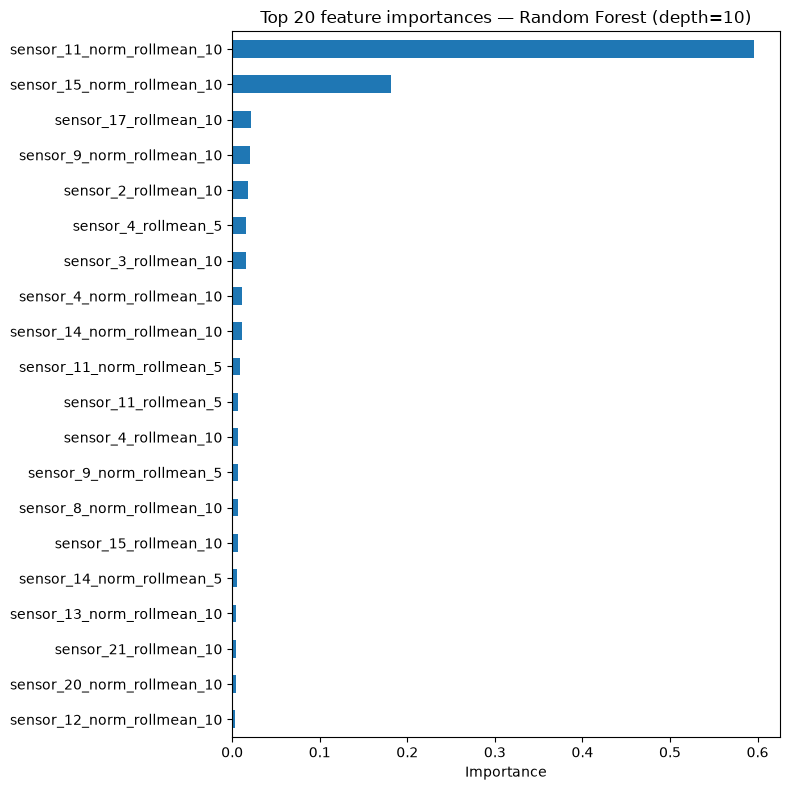

In [17]:
import matplotlib.pyplot as plt

# use the depth=10, n_estimators=1000 model we already decided on
rf_final = RandomForestRegressor(
    n_estimators=1000,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

importances = pd.Series(rf_final.feature_importances_, index=feature_cols).sort_values(ascending=False)

# check how much of total importance the top N features capture
cumulative = importances.cumsum()
print("Top 20 features:")
print(importances.head(20))
print("\nCumulative importance of top 15 features:", cumulative.iloc[14])
print("Cumulative importance of top 20 features:", cumulative.iloc[19])
print("Cumulative importance of top 30 features:", cumulative.iloc[29])

# visualize
plt.figure(figsize=(8, 8))
importances.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 feature importances — Random Forest (depth=10)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [18]:
min_samples_leaf_values = [1, 5, 10, 20, 50]

leaf_results = []

for leaf in min_samples_leaf_values:
    rf_leaf = RandomForestRegressor(
        n_estimators=1000,
        max_depth=10,
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=-1
    )
    rf_leaf.fit(X_train, y_train)

    train_m = evaluate(y_train, rf_leaf.predict(X_train))
    val_m = evaluate(y_val, rf_leaf.predict(X_val))

    leaf_results.append({
        "min_samples_leaf": leaf,
        "train_rmse": train_m["rmse"],
        "val_rmse": val_m["rmse"],
        "gap": val_m["rmse"] - train_m["rmse"],
        "val_nasa_per_row": val_m["nasa_score"] / len(y_val),
    })

leaf_results_df = pd.DataFrame(leaf_results)
print(leaf_results_df)

   min_samples_leaf  train_rmse   val_rmse       gap  val_nasa_per_row
0                 1    5.568055  11.496340  5.928284          2.620162
1                 5    5.741881  11.496579  5.754698          2.622386
2                10    6.104107  11.484847  5.380741          2.605031
3                20    6.887795  11.486380  4.598585          2.592771
4                50    8.603229  11.576288  2.973059          2.561026


In [19]:
# Retrain using only the top 30 most important features
top_30_features = importances.head(30).index.tolist()

X_train_top30 = train_split[top_30_features]
X_val_top30 = val_split[top_30_features]

rf_top30 = RandomForestRegressor(
    n_estimators=1000,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf_top30.fit(X_train_top30, y_train)

train_m30 = evaluate(y_train, rf_top30.predict(X_train_top30))
val_m30 = evaluate(y_val, rf_top30.predict(X_val_top30))

print("Top-30-features model:")
print("Train RMSE:", train_m30["rmse"], "| Val RMSE:", val_m30["rmse"], "| Val NASA/row:", val_m30["nasa_score"] / len(y_val))

print("\nFull-112-features model (min_samples_leaf=20, for comparison):")
print("Val RMSE: 11.486380 | Val NASA/row: 2.592771")

Top-30-features model:
Train RMSE: 7.0301412052939645 | Val RMSE: 11.476350125189331 | Val NASA/row: 2.677972151855033

Full-112-features model (min_samples_leaf=20, for comparison):
Val RMSE: 11.486380 | Val NASA/row: 2.592771


## XG Boost

In [23]:
from xgboost import XGBRegressor

In [24]:
from xgboost import XGBRegressor

max_depth_values = [3, 4, 5, 6]
learning_rate_values = [0.01, 0.05, 0.1, 0.3]
n_estimators_values = [100, 300, 500]

xgb_results = []

for depth in max_depth_values:
    for lr in learning_rate_values:
        for n_est in n_estimators_values:
            xgb_model = XGBRegressor(
                max_depth=depth,
                learning_rate=lr,
                n_estimators=n_est,
                random_state=42,
                n_jobs=-1
            )
            xgb_model.fit(X_train, y_train)   # raw features, same as Random Forest — no scaling needed

            train_m = evaluate(y_train, xgb_model.predict(X_train))
            val_m = evaluate(y_val, xgb_model.predict(X_val))

            xgb_results.append({
                "max_depth": depth,
                "learning_rate": lr,
                "n_estimators": n_est,
                "train_rmse": train_m["rmse"],
                "val_rmse": val_m["rmse"],
                "gap": val_m["rmse"] - train_m["rmse"],
                "val_nasa_per_row": val_m["nasa_score"] / len(y_val),
            })

xgb_results_df = pd.DataFrame(xgb_results)
print(xgb_results_df.sort_values("val_rmse").head(15))

    max_depth  learning_rate  n_estimators  train_rmse   val_rmse        gap  \
26          5           0.01           500    7.542343  11.554466   4.012123   
27          5           0.05           100    7.562394  11.555260   3.992865   
38          6           0.01           500    6.089170  11.580901   5.491732   
39          6           0.05           100    6.069428  11.609809   5.540381   
28          5           0.05           300    5.042991  11.664209   6.621219   
14          4           0.01           500    8.968439  11.692438   2.724000   
29          5           0.05           500    3.780124  11.708627   7.928504   
42          6           0.10           100    4.390702  11.735788   7.345086   
15          4           0.05           100    8.967334  11.739946   2.772611   
37          6           0.01           300    7.574628  11.767068   4.192440   
40          6           0.05           300    3.480726  11.798811   8.318085   
30          5           0.10           1

In [25]:
subsample_values = [0.6, 0.8, 1.0]
min_child_weight_values = [1, 5, 10]

xgb_reg_results = []

for subsample in subsample_values:
    for mcw in min_child_weight_values:
        xgb_model = XGBRegressor(
            max_depth=4,
            learning_rate=0.01,
            n_estimators=500,
            subsample=subsample,
            min_child_weight=mcw,
            random_state=42,
            n_jobs=-1
        )
        xgb_model.fit(X_train, y_train)

        train_m = evaluate(y_train, xgb_model.predict(X_train))
        val_m = evaluate(y_val, xgb_model.predict(X_val))

        xgb_reg_results.append({
            "subsample": subsample,
            "min_child_weight": mcw,
            "train_rmse": train_m["rmse"],
            "val_rmse": val_m["rmse"],
            "gap": val_m["rmse"] - train_m["rmse"],
            "val_nasa_per_row": val_m["nasa_score"] / len(y_val),
        })

xgb_reg_df = pd.DataFrame(xgb_reg_results)
print(xgb_reg_df.sort_values("val_rmse"))


   subsample  min_child_weight  train_rmse   val_rmse       gap  \
4        0.8                 5    8.946141  11.623822  2.677681   
2        0.6                10    8.954921  11.631523  2.676602   
5        0.8                10    8.956906  11.636339  2.679432   
0        0.6                 1    8.951993  11.640194  2.688201   
3        0.8                 1    8.941547  11.643578  2.702031   
1        0.6                 5    8.945509  11.644369  2.698860   
7        1.0                 5    8.962575  11.683386  2.720811   
6        1.0                 1    8.968439  11.692438  2.724000   
8        1.0                10    8.971472  11.692788  2.721317   

   val_nasa_per_row  
4          2.990627  
2          2.955255  
5          2.993205  
0          2.954058  
3          2.996942  
1          2.957505  
7          2.996591  
6          3.009008  
8          3.003638  


In [26]:
from sklearn.model_selection import KFold

# Combine train_split + val_split back together for CV — CV creates its own
# folds, so we want the full pool of 100 engines to draw from, not just 80
all_train_engines = train_final["unit_number"].unique()

candidates = [
    {"subsample": 0.8, "min_child_weight": 5},
    {"subsample": 0.6, "min_child_weight": 10},
    {"subsample": 0.8, "min_child_weight": 10},
]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for candidate in candidates:
    fold_rmses = []

    for fold_num, (train_idx, val_idx) in enumerate(kf.split(all_train_engines)):
        fold_train_engines = all_train_engines[train_idx]
        fold_val_engines = all_train_engines[val_idx]

        fold_train = train_final[train_final["unit_number"].isin(fold_train_engines)]
        fold_val = train_final[train_final["unit_number"].isin(fold_val_engines)]

        X_fold_train = fold_train[feature_cols]
        y_fold_train = fold_train["RUL"]
        X_fold_val = fold_val[feature_cols]
        y_fold_val = fold_val["RUL"]

        model = XGBRegressor(
            max_depth=4,
            learning_rate=0.01,
            n_estimators=500,
            subsample=candidate["subsample"],
            min_child_weight=candidate["min_child_weight"],
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_fold_train, y_fold_train)
        fold_pred = model.predict(X_fold_val)
        fold_rmse = rmse(y_fold_val, fold_pred)
        fold_rmses.append(fold_rmse)

    cv_results.append({
        "subsample": candidate["subsample"],
        "min_child_weight": candidate["min_child_weight"],
        "mean_rmse": np.mean(fold_rmses),
        "std_rmse": np.std(fold_rmses),
        "fold_scores": fold_rmses,
    })

cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)

   subsample  min_child_weight  mean_rmse  std_rmse  \
0        0.8                 5  12.430752  0.563773   
1        0.6                10  12.425879  0.576905   
2        0.8                10  12.425941  0.557281   

                                         fold_scores  
0  [11.623821558028245, 12.679248054626552, 12.30...  
1  [11.631523188581365, 12.653979992329273, 12.25...  
2  [11.636338679851468, 12.67149793813246, 12.291...  


### 5-fold CV on the final Random Forest (top-30 features, depth=10, leaf=20, n_estimators=1000)

In [27]:
rf_fold_rmses = []

for fold_num, (train_idx, val_idx) in enumerate(kf.split(all_train_engines)):
    fold_train_engines = all_train_engines[train_idx]
    fold_val_engines = all_train_engines[val_idx]

    fold_train = train_final[train_final["unit_number"].isin(fold_train_engines)]
    fold_val = train_final[train_final["unit_number"].isin(fold_val_engines)]

    # use top_30_features, consistent with our final chosen Random Forest config
    X_fold_train = fold_train[top_30_features]
    y_fold_train = fold_train["RUL"]
    X_fold_val = fold_val[top_30_features]
    y_fold_val = fold_val["RUL"]

    model = RandomForestRegressor(
        n_estimators=1000,
        max_depth=10,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_fold_train, y_fold_train)
    fold_pred = model.predict(X_fold_val)
    fold_rmse = rmse(y_fold_val, fold_pred)
    rf_fold_rmses.append(fold_rmse)

print("Random Forest CV fold scores:", rf_fold_rmses)
print("Mean RMSE:", np.mean(rf_fold_rmses))
print("Std RMSE:", np.std(rf_fold_rmses))

Random Forest CV fold scores: [11.476350125189333, 13.366846693048362, 12.65692215529603, 13.978978037803488, 12.509370512361967]
Mean RMSE: 12.797693504739836
Std RMSE: 0.8447796810124018


In [28]:
# Save engineered features so Phase 4 doesn't need to redo Phase 2's work
train_final.to_csv("../data/processed/train_final_FD001.csv", index=False)
test_final.to_csv("../data/processed/test_final_FD001.csv", index=False)

print("Saved train_final and test_final to data/processed/")

Saved train_final and test_final to data/processed/


In [29]:
plt.savefig("../reports/figures/model_comparison_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>